# SNP Baseline Models — Raw VCF → Sparse Binary Matrix

Sanity-check pipeline:
1. Parse `sativas413_msu7.vcf` → **scipy sparse binary matrix** (samples × SNPs)
2. Parse `RiceDiversity_44K_Phenotypes_34traits_PLINK.txt` → **StandardScaler'd numpy array**
3. Align samples between the two by NSFTVID
4. Fit quick baseline models (Ridge, Lasso, RF) on a few traits and report Pearson r

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from sklearn.preprocessing import StandardScaler

VCF_PATH      = Path("/home/adickson/rice_data/sativas413_msu7_final.vcf")
PHENO_PATH    = Path("/home/adickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

## 1. VCF → Sparse Binary Matrix

Genotypes are biallelic and homozygous (`0/0` or `1/1`), so the encoding is trivial:
- `0/0` → **0**
- `1/1` → **1**
- `./.` → **0** (treated as reference / missing-as-ref; flagged separately)

Result shape: **(samples × SNPs)** stored as `scipy.sparse.csr_matrix` of `uint8`.

In [2]:
def load_vcf_sparse(vcf_path: Path):
    """
    Parse a biallelic, homozygous VCF into a sparse binary matrix.

    Returns
    -------
    X        : scipy.sparse.csr_matrix, shape (n_samples, n_snps), uint8
    samples  : list[str]  – VCF sample IDs (column headers after FORMAT)
    snp_ids  : list[str]  – SNP IDs from the ID column
    n_missing: int        – total ./. calls (encoded as 0)
    """
    samples, snp_ids = [], []
    rows, cols = [], []   # coordinates of alt-allele calls (value=1)
    n_missing = 0

    # GT token → integer: "0/0"→0, "1/1"→1, "./."→0
    _gt_map = {"0/0": 0, "1/1": 1, "./.": 0}

    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith("##"):
                continue

            fields = line.rstrip("\n").split("\t")

            if line.startswith("#CHROM"):
                # columns 9+ are sample IDs
                samples = fields[9:]
                continue

            snp_idx = len(snp_ids)
            snp_ids.append(fields[2])   # ID column

            gts = fields[9:]
            for samp_idx, gt in enumerate(gts):
                val = _gt_map.get(gt, 0)
                if gt == "./.":
                    n_missing += 1
                if val == 1:
                    rows.append(samp_idx)
                    cols.append(snp_idx)

    n_samples = len(samples)
    n_snps    = len(snp_ids)

    X = sp.csr_matrix(
        (np.ones(len(rows), dtype=np.uint8), (rows, cols)),
        shape=(n_samples, n_snps),
        dtype=np.uint8,
    )
    return X, samples, snp_ids, n_missing


X_vcf, vcf_samples, snp_ids, n_missing = load_vcf_sparse(VCF_PATH)

print(f"Shape (samples × SNPs) : {X_vcf.shape}")
print(f"Stored non-zeros       : {X_vcf.nnz:,}  ({100*X_vcf.nnz/X_vcf.shape[0]/X_vcf.shape[1]:.1f}% density)")
print(f"Missing genotypes (./.): {n_missing:,}")
print(f"Memory (sparse)        : {X_vcf.data.nbytes / 1e6:.1f} MB")
print(f"\nFirst 5 sample IDs: {vcf_samples[:5]}")
print(f"First 5 SNP IDs   : {snp_ids[:5]}")

Shape (samples × SNPs) : (413, 31076)
Stored non-zeros       : 2,932,096  (22.8% density)
Missing genotypes (./.): 530,088
Memory (sparse)        : 2.9 MB

First 5 sample IDs: ['081215-A05_1', '081215-A06_3', '081215-A07_4', '081215-A08_5', '090414-A09_6']
First 5 SNP IDs   : ['id1000001', 'id1000003', 'id1000005', 'id1000007', 'id1000008']



Average alt-allele frequency per sample: 0.2285 (413,) 0.5253250096537521


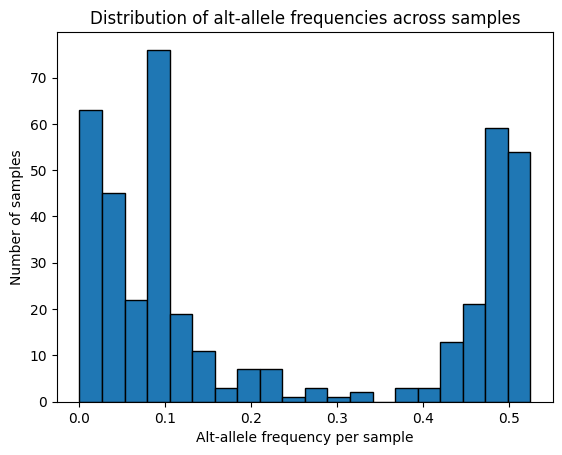

In [14]:
alt_counts = X_vcf.sum(axis=1) / X_vcf.shape[1]
alt_counts = alt_counts.A.flatten()  # convert to 1D array
print(f"\nAverage alt-allele frequency per sample: {alt_counts.mean():.4f}", alt_counts.shape, alt_counts.max())
import matplotlib.pyplot as plt
plt.hist(alt_counts, bins=20, edgecolor='k')
plt.xlabel("Alt-allele frequency per sample")
plt.ylabel("Number of samples")
plt.title("Distribution of alt-allele frequencies across samples")
plt.show()

## 2. Phenotype file → StandardScaler'd numpy array

The phenotype file has two ID columns (`HybID`, `NSFTVID`) followed by 34 trait columns. VCF sample names encode the NSFTVID as the suffix after `_` (e.g. `081215-A05_1` → NSFTVID `1`).

In [12]:
pheno_raw = pd.read_csv(PHENO_PATH, sep="\t")

In [13]:
TRAIT_COLS = [c for c in pheno_raw.columns if c not in ("HybID", "NSFTVID")]
# TRAIT_COLS = [c for c in TRAIT_COLS if not pheno_raw[c].isna().any()]
print(f"{len(TRAIT_COLS)} trait columns:")
print(list(TRAIT_COLS))
CROP_DNA_COLS = ["Panicle number per plant", "Seed number per panicle", "Amylose content", "Alkali spreading value", "Protein content", "Seed length"]

36 trait columns:
['Flowering time at Arkansas', 'Flowering time at Faridpur', 'Flowering time at Aberdeen', 'FT ratio of Arkansas/Aberdeen', 'FT ratio of Faridpur/Aberdeen', 'Culm habit', 'Leaf pubescence', 'Flag leaf length', 'Flag leaf width', 'Awn presence', 'Panicle number per plant', 'Plant height', 'Panicle length', 'Primary panicle branch number', 'Seed number per panicle', 'Florets per panicle', 'Panicle fertility', 'Seed length', 'Seed width', 'Seed volume', 'Seed surface area', 'Brown rice seed length', 'Brown rice seed width', 'Brown rice surface area', 'Brown rice volume', 'Seed length/width ratio', 'Brown rice length/width ratio', 'Seed color ', 'Pericarp color', 'Straighthead suseptability ', 'Blast resistance', 'Amylose content', 'Alkali spreading value', 'Protein content', 'Year07Flowering time at Arkansas', 'Year06Flowering time at Arkansas']


In [14]:
# Extract NSFTVID from VCF sample names (suffix after last '_')
vcf_nsftvid = [int(s.rsplit("_", 1)[-1]) for s in vcf_samples]
vcf_id_to_idx = {nid: i for i, nid in enumerate(vcf_nsftvid)}

# Keep only phenotype rows that have a matching VCF sample
pheno_raw["NSFTVID"] = pheno_raw["NSFTVID"].astype(int)
pheno_matched = pheno_raw[pheno_raw["NSFTVID"].isin(vcf_id_to_idx)].copy()
pheno_matched = pheno_matched.reset_index(drop=True)

print(f"Phenotype rows with VCF match: {len(pheno_matched)} / {len(pheno_raw)}")

# Reorder X rows to match phenotype order
vcf_row_order = [vcf_id_to_idx[nid] for nid in pheno_matched["NSFTVID"]]
X = X_vcf[vcf_row_order, :]   # reordered sparse matrix

print(f"Aligned X shape: {X.shape}")

Phenotype rows with VCF match: 413 / 413
Aligned X shape: (413, 31076)


In [15]:
# Build the scaled phenotype array
# StandardScaler fit on non-NaN values per trait; NaN rows kept as NaN (handled per-trait at model time)
Y_raw = pheno_matched[TRAIT_COLS].values.astype(float)   # (n_samples, n_traits)

scaler = StandardScaler()
# Fit scaler ignoring NaNs: compute mean/std from non-NaN entries per column
Y_scaled = np.full_like(Y_raw, np.nan)
for j in range(Y_raw.shape[1]):
    col = Y_raw[:, j]
    mask = ~np.isnan(col)
    if mask.sum() < 2:
        continue
    mu  = col[mask].mean()
    std = col[mask].std(ddof=0)
    Y_scaled[mask, j] = (col[mask] - mu) / (std if std > 0 else 1.0)

print(f"Y_scaled shape : {Y_scaled.shape}  (samples × traits)")
print(f"NaN counts per trait (first 5):")
for i, t in enumerate(TRAIT_COLS[:5]):
    n_nan = np.isnan(Y_scaled[:, i]).sum()
    print(f"  {t:<45} {n_nan} NaN")

Y_scaled shape : (413, 36)  (samples × traits)
NaN counts per trait (first 5):
  Flowering time at Arkansas                    39 NaN
  Flowering time at Faridpur                    108 NaN
  Flowering time at Aberdeen                    54 NaN
  FT ratio of Arkansas/Aberdeen                 64 NaN
  FT ratio of Faridpur/Aberdeen                 109 NaN


## 3. Sanity checks

Quick look at the data before modelling.

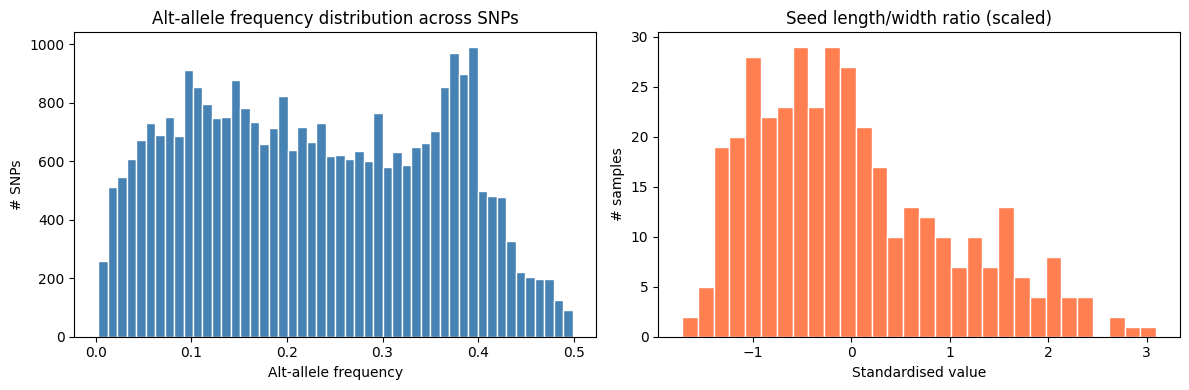


MAF < 0.05 (low-frequency SNPs): 2,437
MAF > 0.95 (near-fixed SNPs)   : 0


In [16]:
import matplotlib.pyplot as plt

# --- SNP alt-allele frequency distribution ---
allele_freq = np.asarray(X.mean(axis=0)).ravel()   # fraction of samples with alt allele

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(allele_freq, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Alt-allele frequency distribution across SNPs")
axes[0].set_xlabel("Alt-allele frequency")
axes[0].set_ylabel("# SNPs")

# --- Trait distribution of a continuous trait ---
trait_ex = TRAIT_COLS[25]
trait_idx = TRAIT_COLS.index(trait_ex)
y_trait   = Y_scaled[:, trait_idx]
axes[1].hist(y_trait[~np.isnan(y_trait)], bins=30, color="coral", edgecolor="white")
axes[1].set_title(f"{trait_ex} (scaled)")
axes[1].set_xlabel("Standardised value")
axes[1].set_ylabel("# samples")

plt.tight_layout()
plt.show()

print(f"\nMAF < 0.05 (low-frequency SNPs): {(allele_freq < 0.05).sum():,}")
print(f"MAF > 0.95 (near-fixed SNPs)   : {(allele_freq > 0.95).sum():,}")

## 4. Baseline models

Run Ridge, Lasso, and Random Forest on a handful of traits using 5-fold CV. Reports Pearson r and R² on held-out folds.

The sparse matrix is converted to dense here — for proper large-scale runs you'd want `sklearn` sparse-compatible pipelines or PCA dimensionality reduction first.

In [17]:
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score


# Reduce dimensionality with TruncatedSVD (works natively on sparse matrices)
# Use 120 components — fast, keeps most variance for a quick sanity check
print("Fitting TruncatedSVD (120 components) on sparse SNP matrix...")
svd = TruncatedSVD(n_components=120, random_state=42)
X_svd = svd.fit_transform(X)   # (n_samples, 120)
print(f"Explained variance ratio (first 10 components): "
      f"{svd.explained_variance_ratio_[:10].round(3)}")
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")

def cv_eval(X_feat, y, models, n_splits=5, random_state=42):
    """5-fold CV returning mean Pearson r and R² per model."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = {name: {"pearson_r": [], "r2": []} for name, _ in models}

    for train_idx, test_idx in kf.split(X_feat):
        X_tr, X_te = X_feat[train_idx], X_feat[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        for name, model in models:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            r, _ = pearsonr(y_te, y_pred)
            results[name]["pearson_r"].append(r)
            results[name]["r2"].append(r2_score(y_te, y_pred))

    return {
        name: {
            "pearson_r": np.mean(vals["pearson_r"]),
            "r2":        np.mean(vals["r2"]),
            "n_splits": n_splits,
            "model": model,
            "r2_std": np.std(vals["r2"]),
            "pearson_r_std": np.std(vals["pearson_r"]),
        }
        for name, vals in results.items()
    }

MODELS = [
    ("Ridge",  Ridge(alpha=1.0)),
    ("Lasso",  Lasso(alpha=0.04, max_iter=5000)),
    ("RF-100", RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
    ("GBR-100", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

# Traits to evaluate — pick a mix of continuous and binary-ish ones
# EVAL_TRAITS = [
#     "Flowering time at Arkansas",
#     "Plant height",
#     "Seed length",
#     "Amylose content",
#     "Protein content",
# ]

EVAL_TRAITS = TRAIT_COLS  # evaluate all traits

all_rows = []
for trait in EVAL_TRAITS:
    t_idx = TRAIT_COLS.index(trait)
    y_t   = Y_scaled[:, t_idx]
    mask  = ~np.isnan(y_t)
    if mask.sum() < 30:
        print(f"Skipping {trait!r} — too few non-NaN samples ({mask.sum()})")
        continue

    res = cv_eval(X_svd[mask], y_t[mask], MODELS)
    for model_name, metrics in res.items():
        all_rows.append({
            "Trait": trait,
            "Model": model_name,
            "Pearson r": round(metrics["pearson_r"], 4) if metrics["pearson_r"] is not None else None,
            "R²":        round(metrics["r2"],        4) if metrics["r2"] is not None else None,
            "R² std":     round(metrics["r2_std"], 4) if metrics["r2_std"] is not None else None,
            "Pearson r std": round(metrics["pearson_r_std"], 4) if metrics["pearson_r_std"] is not None else None,
            "n_samples": int(mask.sum()),
        })

results_df = pd.DataFrame(all_rows)
results_df = results_df.sort_values(["Trait", "Pearson r"], ascending=[True, False])
results_df

Fitting TruncatedSVD (120 components) on sparse SNP matrix...
Explained variance ratio (first 10 components): [0.399 0.095 0.06  0.023 0.014 0.012 0.011 0.009 0.008 0.007]
Total variance explained: 0.885


,Trait,Model,Pearson r,R²,R² std,Pearson r std,n_samples
130,Alkali spreading value,RF-100,0.4534,0.1911,0.0489,0.0612,403
131,Alkali spreading value,GBR-100,0.4188,0.1417,0.0911,0.0869,403
129,Alkali spreading value,Lasso,0.3419,-0.0523,0.0928,0.0994,403
128,Alkali spreading value,Ridge,0.0494,-2.5842,0.5846,0.1182,403
125,Amylose content,Lasso,0.7402,0.5312,0.0668,0.0397,401
...,...,...,...,...,...,...,...
140,Year06Flowering time at Arkansas,Ridge,0.3069,-2.9382,1.8498,0.0909,337
138,Year07Flowering time at Arkansas,RF-100,0.5873,0.3376,0.0791,0.0633,367
139,Year07Flowering time at Arkansas,GBR-100,0.5700,0.3101,0.0553,0.0453,367
137,Year07Flowering time at Arkansas,Lasso,0.5631,0.2561,0.0573,0.0747,367


In [18]:
for trait in EVAL_TRAITS:
    trait_rows = results_df[results_df["Trait"] == trait]
    print(f"\nTrait: {trait}")
    print(trait_rows[["Model", "Pearson r", "R²", "n_samples"]])


Trait: Flowering time at Arkansas
     Model  Pearson r      R²  n_samples
3  GBR-100     0.5770  0.3040        374
2   RF-100     0.5760  0.3182        374
1    Lasso     0.5755  0.2736        374
0    Ridge     0.3529 -0.8559        374

Trait: Flowering time at Faridpur
     Model  Pearson r      R²  n_samples
6   RF-100     0.4097  0.1125        305
5    Lasso     0.3757 -0.0568        305
7  GBR-100     0.3629 -0.0199        305
4    Ridge     0.1695 -7.0087        305

Trait: Flowering time at Aberdeen
      Model  Pearson r      R²  n_samples
11  GBR-100     0.4744  0.1746        359
10   RF-100     0.4722  0.1807        359
9     Lasso     0.4506  0.0645        359
8     Ridge     0.3072 -2.5761        359

Trait: FT ratio of Arkansas/Aberdeen
      Model  Pearson r      R²  n_samples
14   RF-100     0.5149  0.2493        349
15  GBR-100     0.4594  0.1852        349
13    Lasso     0.4062  0.0551        349
12    Ridge     0.1955 -3.7084        349

Trait: FT ratio of Faridpu

In [8]:
from sklearn.impute import KNNImputer

print(f"NaN counts before imputation: {np.isnan(Y_scaled).sum()}")

imputer = KNNImputer(n_neighbors=10)
Y_imputed = imputer.fit_transform(Y_scaled)  # (413, 36), no NaNs

print(f"NaN counts after imputation:  {np.isnan(Y_imputed).sum()}")
print(f"Y_imputed shape: {Y_imputed.shape}")


NaN counts before imputation: 1598
NaN counts after imputation:  0
Y_imputed shape: (413, 36)


In [9]:
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Reduce dimensionality with TruncatedSVD (works natively on sparse matrices)
# Use 120 components — fast, keeps most variance for a quick sanity check
print("Fitting TruncatedSVD (120 components) on sparse SNP matrix...")
svd = TruncatedSVD(n_components=120, random_state=42)
X_svd = svd.fit_transform(X)   # (n_samples, 120)
print(f"Explained variance ratio (first 10 components): "
      f"{svd.explained_variance_ratio_[:10].round(3)}")
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")

Fitting TruncatedSVD (120 components) on sparse SNP matrix...
Explained variance ratio (first 10 components): [0.294 0.106 0.082 0.062 0.023 0.015 0.012 0.01  0.009 0.008]
Total variance explained: 0.863


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import MultiTaskLasso
# Split data into train/test sets (80/20 split)
X_train, X_test, Y_train, Y_test, Y_train_imputed, Y_test_imputed = train_test_split(
    X_svd, Y_scaled, Y_imputed, test_size=0.2, random_state=42
)
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
models = [#XGBRegressor(n_estimators=10, random_state=42, missing=np.nan),
          Lasso(alpha=0.1, random_state=42),
          MultiTaskLasso(alpha=0.9, random_state=42)
          ]
eval_rows = []
for model in models:
    model_name = type(model).__name__
    print(f"\nTraining {model_name}...")
    model.fit(X_train, Y_train_imputed)
    Y_pred = model.predict(X_test)
    for j, trait in enumerate(TRAIT_COLS):
        nan_mask = np.isnan(Y_test[:, j])
        r_test_j = pearsonr(Y_test[~nan_mask, j], Y_pred[~nan_mask, j])[0]
        r2 = r2_score(Y_test[~nan_mask, j], Y_pred[~nan_mask, j])
        eval_rows.append({
            "model": model_name,
            "trait": trait,
            "pearson_r": r_test_j,
            "r2": r2
        })
        # print(f"{trait:<45}  Pearson r: {r_test_j:.3f} , R²: {r2:.3f}")
    



Training Lasso...

Training MultiTaskLasso...


In [33]:
# Display evaluation results
eval_df = pd.DataFrame(eval_rows)
print("\nModel evaluation results:")
print(eval_df.pivot(index="trait", columns="model", values="pearson_r").round(3))
print("\nR² scores:")
print(eval_df.pivot(index="trait", columns="model", values="r2").round(3))


Model evaluation results:
model                             Lasso  MultiTaskLasso
trait                                                  
Alkali spreading value            0.556           0.611
Amylose content                   0.709           0.643
Awn presence                      0.569           0.507
Blast resistance                  0.620           0.651
Brown rice length/width ratio     0.837           0.827
Brown rice seed length            0.822           0.806
Brown rice seed width             0.837           0.824
Brown rice surface area           0.752           0.771
Brown rice volume                 0.786           0.797
Culm habit                        0.681           0.733
FT ratio of Arkansas/Aberdeen     0.493           0.550
FT ratio of Faridpur/Aberdeen     0.485           0.386
Flag leaf length                  0.081           0.355
Flag leaf width                   0.758           0.797
Florets per panicle               0.509           0.624
Flowering time at Abe

In [35]:
print(np.isnan(Y_scaled).sum(axis=0))  # NaN counts per trait


[ 39 108  54  64 109  29 125  36  36  44  41  30  38  38  37  36  37  36
  36  36  36  36  36  36  36  36  36  36  36  73  28  12  10  20  46  76]


,Trait,Model,Pearson r,R²,R² std,Pearson r std,n_samples
130,Alkali spreading value,RF-100,0.4683,0.2045,0.0375,0.0543,403
131,Alkali spreading value,GBR-100,0.3991,0.1108,0.0213,0.0352,403
129,Alkali spreading value,Lasso,0.3527,-0.0332,0.1589,0.1093,403
128,Alkali spreading value,Ridge,0.1878,-0.9994,0.4623,0.1125,403
127,Amylose content,GBR-100,0.7564,0.5657,0.0293,0.0201,401
...,...,...,...,...,...,...,...
140,Year06Flowering time at Arkansas,Ridge,0.4478,-0.6406,0.2987,0.0502,337
138,Year07Flowering time at Arkansas,RF-100,0.5983,0.3548,0.0873,0.0768,367
139,Year07Flowering time at Arkansas,GBR-100,0.5599,0.3000,0.1003,0.0845,367
137,Year07Flowering time at Arkansas,Lasso,0.5090,0.1412,0.1083,0.0840,367


In [46]:
for trait, subdf in results_df[["Trait", "Model", "Pearson r", "R²", "R² std"]].groupby("Trait"):
    print(f"\nTrait: {trait}")
    print(subdf[["Model", "Pearson r", "R²", "R² std"]].to_string(index=False))


Trait: Alkali spreading value
  Model  Pearson r      R²  R² std
 RF-100     0.4683  0.2045  0.0375
GBR-100     0.3991  0.1108  0.0213
  Lasso     0.3527 -0.0332  0.1589
  Ridge     0.1878 -0.9994  0.4623

Trait: Amylose content
  Model  Pearson r     R²  R² std
GBR-100     0.7564 0.5657  0.0293
  Lasso     0.7469 0.5356  0.0761
 RF-100     0.7434 0.5463  0.0242
  Ridge     0.6394 0.2363  0.1767

Trait: Awn presence
  Model  Pearson r      R²  R² std
GBR-100     0.3584  0.0745  0.0976
 RF-100     0.3567  0.1095  0.1039
  Lasso     0.2864 -0.1334  0.1384
  Ridge     0.1881 -1.1481  0.3881

Trait: Blast resistance
  Model  Pearson r      R²  R² std
  Lasso     0.6393  0.3639  0.0936
 RF-100     0.6337  0.3865  0.0781
GBR-100     0.6153  0.3654  0.0718
  Ridge     0.5543 -0.0400  0.4541

Trait: Brown rice length/width ratio
  Model  Pearson r      R²  R² std
  Lasso     0.7806  0.5926  0.0421
 RF-100     0.7283  0.5132  0.0377
GBR-100     0.7127  0.4880  0.0431
  Ridge     0.5981 -0.1483

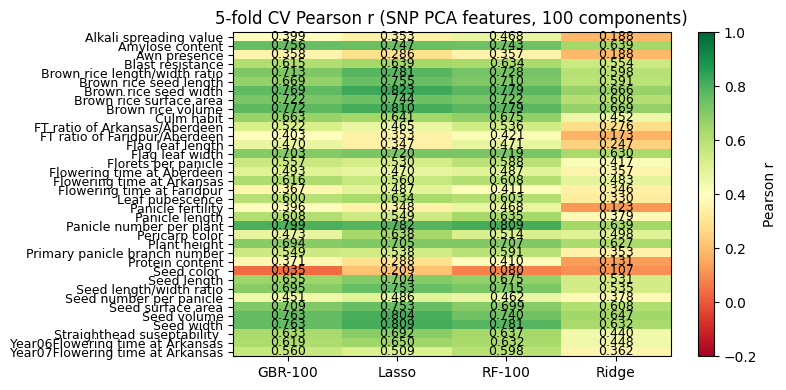

In [47]:
# Heatmap of Pearson r across traits × models
pivot = results_df.pivot(index="Trait", columns="Model", values="Pearson r")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("5-fold CV Pearson r (SNP PCA features, 100 components)")
plt.colorbar(im, ax=ax, label="Pearson r")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()